In [1]:
import math
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:
a = [2, 3, 1, 2, 4, 5, 1]
b = [2, 3, 5, 1]
max_len = 20
a_split = max_len //2
a[:a_split] + b[:max_len - a_split]

[2, 3, 1, 2, 4, 5, 1, 2, 3, 5, 1]

In [3]:
def get_random_word(vocab_words):
    i = random.randint(0, len(vocab_words)-1)
    return vocab_words[i]

In [4]:
from collections import Counter
def preprocess(line):
    return line.lower().split()
PAD_IDX = 0
CLS_IDX = 1
SEP_IDX = 2
MASK_IDX = 3
UNK_IDX = 4
class Vocab:
    def __init__(self, file=None):
        self.c = Counter()
        self.word2idx = {
            "<pad>": PAD_IDX,
            "<cls>": CLS_IDX,
            "<sep>": SEP_IDX,
            "<mask>": MASK_IDX,
            "<unk>": UNK_IDX,
        }
        self.idx2word = {
            PAD_IDX: "<pad>",
            CLS_IDX: "<cls>",
            SEP_IDX: "<sep>",
            MASK_IDX: "<mask>",
            UNK_IDX: "<unk>",
        }
        if file is not None:
            self._update(file)
    def _update(self, file):
        with open(file, "r", encoding="utf-8") as f:
            for line in f:
                self.c.update(preprocess(line))
        # Add only words that aren't already in the vocabulary
        for word, _ in sorted(
            self.c.items(),
            key=lambda item: (-item[1], item[0])
        ):
            if word not in self.word2idx:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx] = word
    def __len__(self):
        return len(self.word2idx)
    def __getitem__(self, word):
        return self.word2idx.get(word, UNK_IDX)
    def encode(self, line):
        return [self[word] for word in preprocess(line)]
    def decode(self, indices):
        return [self.idx2word.get(i, "<unk>") for i in indices]

vocab = Vocab("train_data.txt")
len(vocab)

28915

In [5]:
import six
def convert_to_unicode(text):
  """Converts `text` to Unicode (if it's not already), assuming utf-8 input."""
  if six.PY3:
    if isinstance(text, str):
      return text
    elif isinstance(text, bytes):
      return text.decode("utf-8", "ignore")
    else:
      raise ValueError("Unsupported string type: %s" % (type(text)))
  elif six.PY2:
    if isinstance(text, str):
      return text.decode("utf-8", "ignore")
    elif isinstance(text, unicode):
      return text
    else:
      raise ValueError("Unsupported string type: %s" % (type(text)))
  else:
    raise ValueError("Not running on Python2 or Python 3?")

In [6]:
from tokenizers import Tokenizer
from tokenizers.models import WordPiece
from tokenizers.trainers import WordPieceTrainer
from tokenizers.pre_tokenizers import Whitespace


tokenizer = Tokenizer(
    WordPiece(unk_token="<unk>")
)

tokenizer.pre_tokenizer = Whitespace()
VOCAB_SIZE=30000
trainer = WordPieceTrainer(
    vocab_size=VOCAB_SIZE,
    special_tokens=[
        "<pad>",
        "<cls>",
        "<sep>",
        "<mask>",
        "<unk>",
    ]
)

tokenizer.train(
    ["train_data.txt"],
    trainer
)

In [7]:
output = tokenizer.encode("the transformer is powerful")

print(output.tokens)
print(output.ids)

['the', 'transform', '##er', 'is', 'powerful']
[452, 14085, 453, 519, 3957]


In [8]:
print(tokenizer.decode(output.ids))

the transform ##er is powerful


In [9]:
tokenizer.save("tokenizer-config.json")

In [10]:
tokenizer.encode("hello world").tokens

['hell', '##o', 'world']

In [11]:
vocab._update("val_data.txt")
vocab._update("test_data.txt")
len(vocab)

28915

In [12]:
indexer = vocab.encode
indexer("I am a good boy")

[76, 1740, 12, 429, 1369]

In [13]:
class PipelineForPretrain:
    def __init__(
        self,
        tokenizer,
        max_pred=20,
        mask_prob=0.15,
        max_len=512
    ):
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.max_pred = max_pred
        self.mask_prob = mask_prob

        # Tokenizer vocabulary
        self.vocab_words = list(tokenizer.get_vocab().keys())

        # Get IDs from the tokenizer itself
        self.pad_id = tokenizer.token_to_id("<pad>")
        self.cls_id = tokenizer.token_to_id("<cls>")
        self.sep_id = tokenizer.token_to_id("<sep>")
        self.mask_id = tokenizer.token_to_id("<mask>")
        self.unk_id = tokenizer.token_to_id("<unk>")

    def tokenize_words(self, words):
        """
        Convert a list of whitespace-separated words into
        WordPiece tokens.
        """
        tokens = []

        for word in words:
            encoding = self.tokenizer.encode(word)
            tokens.extend(encoding.tokens)

        return tokens

    def token_to_id(self, token):
        idx = self.tokenizer.token_to_id(token)
        return self.unk_id if idx is None else idx

    def __call__(self, instance):

        is_not_next, words_a, words_b = instance

        # --------------------------------------------------
        # 1. WordPiece tokenization
        # --------------------------------------------------

        tokens_a = self.tokenize_words(words_a)
        tokens_b = self.tokenize_words(words_b)

        # --------------------------------------------------
        # 2. Make sure the FINAL sequence is <= max_len
        #
        # [CLS] A [SEP] B [SEP]
        #       1    1   1 special tokens
        # --------------------------------------------------

        available_len = self.max_len - 3

        while len(tokens_a) + len(tokens_b) > available_len:

            if len(tokens_a) > len(tokens_b):
                tokens_a.pop()
            else:
                tokens_b.pop()

        # --------------------------------------------------
        # 3. Add special tokens
        # --------------------------------------------------

        tokens = (
            ["<cls>"]
            + tokens_a
            + ["<sep>"]
            + tokens_b
            + ["<sep>"]
        )

        segment_ids = (
            [0] * (len(tokens_a) + 2)
            + [1] * (len(tokens_b) + 1)
        )

        input_mask = [1] * len(tokens)

        # --------------------------------------------------
        # 4. Masked Language Model
        # --------------------------------------------------

        masked_tokens = []
        masked_pos = []

        n_pred = min(
            self.max_pred,
            max(1, round(len(tokens) * self.mask_prob))
        )

        cand_pos = [
            i
            for i, token in enumerate(tokens)
            if token not in ("<cls>", "<sep>")
        ]

        random.shuffle(cand_pos)

        for pos in cand_pos[:n_pred]:

            masked_tokens.append(tokens[pos])
            masked_pos.append(pos)

            r = random.random()

            if r < 0.8:
                # 80% -> <mask>
                tokens[pos] = "<mask>"

            elif r < 0.9:
                # 10% -> random token
                tokens[pos] = random.choice(
                    self.vocab_words
                )

            # else:
            # 10% -> keep original token

        masked_weights = [1] * len(masked_tokens)

        # --------------------------------------------------
        # 5. Convert tokens directly to IDs
        # --------------------------------------------------

        input_ids = [
            self.token_to_id(token)
            for token in tokens
        ]

        masked_ids = [
            self.token_to_id(token)
            for token in masked_tokens
        ]

        # --------------------------------------------------
        # 6. Pad sequence to max_len
        # --------------------------------------------------

        n_pad = self.max_len - len(input_ids)

        input_ids.extend([self.pad_id] * n_pad)
        segment_ids.extend([0] * n_pad)
        input_mask.extend([0] * n_pad)

        # --------------------------------------------------
        # 7. Pad MLM targets to max_pred
        # --------------------------------------------------

        n_pred_pad = self.max_pred - len(masked_ids)

        masked_ids.extend([self.pad_id] * n_pred_pad)
        masked_pos.extend([0] * n_pred_pad)
        masked_weights.extend([0] * n_pred_pad)

        return (
            input_ids,
            segment_ids,
            input_mask,
            masked_ids,
            masked_pos,
            masked_weights,
            is_not_next
        )

class SentencePairDataLoader:
    def __init__(self, file, pipeline, batch_size=32, max_len=512):
        self.max_len=max_len
        self.batch_size=batch_size
        self.short_sampling_prob=0.1
        with open(file, "r") as f:
            self.lines = f.readlines()
        self.a_pos = 0
        self.tot_lines = len(self.lines)
        self.pipeline = pipeline
    def read_tokens(self, line_number, length):
        flag = False # check if line number is changed or not
        while True:
            line = self.lines[line_number]
            tokens = preprocess(line)
            if not tokens or tokens[0] == '=':
                line_number = (line_number + 1) % self.tot_lines
                flag = True
                continue
            break
        tokens = tokens[:length]
        line_number = (line_number + 1) % self.tot_lines
        return tokens, line_number, flag
    def set_random_offset(self):
        return random.randint(0, self.tot_lines - 1)
    def __len__(self):
        return self.tot_lines // self.batch_size
    def __iter__(self):
        self.a_pos = 0
        for _ in range(len(self)):
            batch = []
            for _ in range(self.batch_size):
                len_tokens = random.randint(1, int(self.max_len / 2)) if random.random() < self.short_sampling_prob else int(self.max_len / 2)
                is_not_next = random.random() < 0.5
                tokens_a, self.a_pos, _ = self.read_tokens(self.a_pos, len_tokens)
                b_next = self.set_random_offset() if is_not_next else self.a_pos + 1
                if b_next == self.tot_lines:
                    b_next = 0
                tokens_b, _, fg = self.read_tokens(b_next, len_tokens)
                flag = (b_next != (self.a_pos + 1)) or fg
                if flag is True:
                    is_not_next = True
                instance = (is_not_next, tokens_a, tokens_b)
                for proc in self.pipeline:
                    instance = proc(instance)
                batch.append(instance)
            batch_tensors = [torch.tensor(x, dtype=torch.long) for x in zip(*batch)]
            yield batch_tensors

In [14]:
MAX_LEN = 256

In [15]:
len(tokenizer.get_vocab().keys())

30000

In [16]:
pipeline = [
    PipelineForPretrain(
        tokenizer=tokenizer,
        max_pred=20,
        mask_prob=0.15,
        max_len=MAX_LEN
    )
]

BATCH_SIZE = 16

train_loader = SentencePairDataLoader(
    "train_data.txt",
    pipeline=pipeline,
    batch_size=BATCH_SIZE,
    max_len=MAX_LEN
)

val_loader = SentencePairDataLoader(
    "val_data.txt",
    pipeline=pipeline,
    batch_size=BATCH_SIZE,
    max_len=MAX_LEN
)

In [ ]:
input_ids, segment_ids, input_mask, masked_ids, masked_pos, masked_weights, is_not_next = next(iter(train_loader))
print(input_ids[0])

In [18]:
gelu = lambda x : x * 0.5 * (1.0 + torch.erf(x / math.sqrt(2.0)))
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, dim=768, dropout=0.1, n_heads=12):
        super().__init__()
        self.proj_q = nn.Linear(dim, dim)
        self.proj_k = nn.Linear(dim, dim)
        self.proj_v = nn.Linear(dim, dim)
        self.drop = nn.Dropout(dropout)
        self.scores = None
        self.n_heads = n_heads
    def forward(self, x, mask):
        # x: b,s,d, mask: b,s
        b, s, d = x.shape
        # b, s, d -> b, s, d
        q, k, v = self.proj_q(x), self.proj_k(x), self.proj_v(x)
        # b, s, d -> b, s, h, w -> b, h, s, w
        q = q.reshape(b, s, self.n_heads, -1).transpose(1, 2)
        k = k.reshape(b, s, self.n_heads, -1).transpose(1, 2)
        v = v.reshape(b, s, self.n_heads, -1).transpose(1, 2)
        # b, h, s, w @ b, h, w, s = b, h, s, s
        scores = q @ k.transpose(-2, -1) /  np.sqrt(d // self.n_heads)
        if mask is not None:
            mask = mask[:, None, None, :].float() # b, 1, 1, s
            scores -= 10000.0 * (1.0 - mask)
        scores = self.drop(nn.functional.softmax(scores, dim=-1))
        h = (scores @ v).transpose(1, 2).contiguous() # b, s, h, w
        h = h.reshape(b, s, d)
        self.scores = scores
        return h
class PositionWiseFF(nn.Module):
    def __init__(self, dim=768, dim_ff=3072):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim_ff)
        self.fc2 = nn.Linear(dim_ff, dim)
    def forward(self, x):
        return self.fc2(gelu(self.fc1(x)))
class LayerNorm(nn.Module):
    def __init__(self, dim=768, variance_epsilon=1e-12):
        super().__init__()
        self.gamma = nn.Parameter(torch.ones(dim))
        self.beta = nn.Parameter(torch.zeros(dim))
        self.variance_epsilon = variance_epsilon
    def forward(self, x):
        u = x.mean(-1, keepdim=True)
        s = (x - u).pow(2).mean(-1, keepdim=True)
        x = (x - u) / torch.sqrt(s + self.variance_epsilon)
        return self.gamma * x + self.beta

In [19]:
def Embedding(num_emb, emb_dim, padding_idx=None):
    m = nn.Embedding(num_emb, emb_dim, padding_idx)
    nn.init.normal_(m.weight, mean=0, std=emb_dim ** -0.5)
    nn.init.constant_(m.weight[padding_idx], 0)
    return m
class Embeddings(nn.Module):
    def __init__(self, vocab_size, dim=768, max_len=512, n_segments=2, position_embeds=True, segment_embeds=True, dropout=0.1):
        super().__init__()
        self.tok_embed = Embedding(vocab_size, dim)
        self.pos_embed = Embedding(max_len, dim) if position_embeds else None
        self.seg_embed = Embedding(n_segments, dim) if segment_embeds else None
        self.norm = LayerNorm(dim)
        self.drop = nn.Dropout(dropout)
    def forward(self, x, seg):
        e = self.tok_embed(x)
        if self.pos_embed is not None:
            pos = torch.arange(x.size(1), dtype=torch.long, device=x.device)
            pos = pos.unsqueeze(0).expand_as(x)
            e = e + self.pos_embed(pos)
        if self.seg_embed is not None:
            e = e + self.seg_embed(seg)
        return self.drop(self.norm(e))
class Block(nn.Module):
    def __init__(self, dim=768, dim_ff=3072, n_heads=12, dropout=0.1):
        super().__init__()
        self.attn = MultiHeadSelfAttention(dim, dropout, n_heads)
        self.proj = nn.Linear(dim, dim)
        self.norm1 = LayerNorm(dim)
        self.pwff = PositionWiseFF(dim, dim_ff)
        self.norm2 = LayerNorm(dim)
        self.drop = nn.Dropout(dropout)
    def forward(self, x, mask):
        h = self.attn(x, mask)
        h = self.norm1(x + self.drop(self.proj(h)))
        h = self.norm2(h + self.drop(self.pwff(h)))
        return h
class BERT(nn.Module):
    def __init__(self, vocab_size, dim=768, dim_ff=3072, max_len=512, n_heads = 12, n_layers=12, dropout=0.1):
        super().__init__()
        self.dim = dim
        self.embed = Embeddings(vocab_size, dim, max_len)
        self.blocks = nn.ModuleList([Block(dim, dim_ff, n_heads, dropout) for _ in range(n_layers)])
    def forward(self, x, seg, mask):
        h = self.embed(x, seg)
        for block in self.blocks:
            h = block(h, mask)
        return h

In [20]:
class BERTPretrain(nn.Module):
    def __init__(self, transformer: BERT):
        super().__init__()
        self.transformer = transformer
        dim = transformer.dim
        # for sentence classification
        self.pooler = nn.Linear(dim, dim)
        self.pooler_activation = nn.Tanh()
        self.seq_relationship = nn.Linear(dim, 2)

        # for masked LM
        embed_weight = self.transformer.embed.tok_embed.weight
        n_vocab, n_dim = embed_weight.size()
        self.decoder_linear = nn.Linear(dim, dim)
        self.decoder_norm = LayerNorm(dim)
        self.decoder_output = nn.Linear(n_dim, n_vocab, bias=False)
        self.decoder_output_bias = nn.Parameter(torch.zeros(n_vocab))

        self.decoder_output.weights = self.transformer.embed.tok_embed.weight
    def forward(self, input_ids, segment_ids=None, input_mask=None, masked_pos=None):
        segment_ids = torch.zeros_like(input_ids) if segment_ids is None else segment_ids
        input_mask = torch.ones_like(input_ids) if input_mask is None else input_mask
        h = self.transformer(input_ids, segment_ids, input_mask)

        # sentence classification
        pooled_h = self.pooler_activation(self.pooler(h[:, 0]))
        logits_clsf = self.seq_relationship(pooled_h)

        # for masked lm
        masked_pos = masked_pos[:, :, None].expand(-1, -1, h.size(-1))
        h_masked = h if masked_pos is None else torch.gather(h, 1, masked_pos)
        h_masked = self.decoder_norm(gelu(self.decoder_linear(h_masked)))
        logits_lm = self.decoder_output(h_masked) + self.decoder_output_bias
        return logits_lm, logits_clsf

class BERTClassification(nn.Module):
    def __init__(self, transformer: BERT, num_classes):
        super().__init__()
        self.transformer = transformer
        dim = transformer.dim
        self.pooler = nn.Linear(dim, dim)
        self.pooler_activation = nn.Tanh()
        self.dropout = nn.Dropout(0.1)
        self.classifier = nn.Linear(dim, num_classes)
    def forward(self, input_ids, segment_ids=None, input_mask=None):
        segment_ids = torch.zeros_like(input_ids) if segment_ids is None else segment_ids
        input_mask = torch.ones_like(input_ids) if  input_mask is None else input_mask
        h = self.transformer(input_ids, segment_ids, input_mask)
        pooled_h = self.pooler_activation(self.pooler(h[:, 0]))
        pooled_h = self.dropout(pooled_h)
        logits = self.classifier(pooled_h)
        return logits

In [21]:
body = BERT(vocab_size=VOCAB_SIZE, dim=256, dim_ff=1024, n_layers=4, n_heads=4, max_len=MAX_LEN)
model = BERTPretrain(body)

In [22]:
from tqdm import tqdm
def train_epoch(model, dataloader, optimizer, epoch, device):
    model.train()
    total_loss = 0.0
    total_steps = 0
    for batch in tqdm(dataloader, desc=f"[Epoch {epoch+1:3d}] Batch "):
        batch = tuple(t.to(device) for t in batch)
        input_ids, segment_ids, input_mask, masked_ids, masked_pos, masked_weights, is_not_next = batch
        logits_lm, logits_sc = model(input_ids, segment_ids, input_mask, masked_pos)
        loss_lm = nn.functional.cross_entropy(logits_lm.transpose(1, 2), masked_ids, reduction='none')
        loss_lm = (loss_lm * masked_weights.float()).mean()
        loss_sc = nn.functional.cross_entropy(logits_sc, is_not_next)
        loss = loss_lm + loss_sc
        loss.backward()
        total_loss += loss.item()
        total_steps += 1
        optimizer.step()
        optimizer.zero_grad()
    train_loss = total_loss / total_steps
    # print(f"Train loss: {train_loss}")
    return train_loss
def evaluate(model, dataloader, device):
    model.eval()
    total_loss = 0.0
    total_steps = 0
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Validation "):
            batch = tuple(t.to(device) for t in batch)
            input_ids, segment_ids, input_mask, masked_ids, masked_pos, masked_weights, is_not_next = batch
            logits_lm, logits_sc = model(input_ids, segment_ids, input_mask, masked_pos)
            loss_lm = nn.functional.cross_entropy(logits_lm.transpose(1, 2), masked_ids, reduction='none')
            loss_lm = (loss_lm * masked_weights.float()).mean()
            loss_sc = nn.functional.cross_entropy(logits_sc, is_not_next)
            loss = loss_lm + loss_sc
            total_loss += loss.item()
            total_steps += 1
    val_loss = total_loss / total_steps
    # print(f"Val loss: {val_loss}")
    return val_loss

In [ ]:
train_losses = []
val_losses = []
optimizer = torch.optim.AdamW(params=model.parameters())
model = model.to(device)
NUM_EPOCHS=50
for epoch in range(NUM_EPOCHS):
    train_loss = train_epoch(model, train_loader, optimizer, epoch, device)
    val_loss = evaluate(model, val_loader, device)
    print(f"Epoch: {epoch + 1:2d}, Train loss: {train_loss:.4f}, Val loss: {val_loss:.4f}")
    train_losses.append(train_loss)
    val_losses.append(val_loss)

In [24]:
torch.save(body.state_dict(), "bert-sbjt.pt")

In [26]:
body = BERT(vocab_size=VOCAB_SIZE, dim=256, dim_ff=1024, n_layers=4, n_heads=4, max_len=MAX_LEN)
body.load_state_dict(torch.load("bert-sbjt.pt"))
print("loaded")

loaded


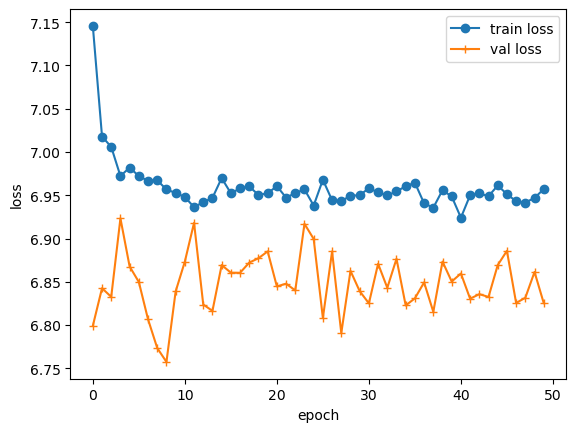

In [27]:
import matplotlib.pyplot as plt
plt.plot(train_losses, marker='o', label='train loss')
plt.plot(val_losses, marker='+', label='val loss')
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

```bash
output_modes = {
    "cola": "classification",
    "mnli": "classification",
    "mrpc": "classification",
    "sst-2": "classification",
    "sts-b": "regression",
    "qqp": "classification", # quora question pairs <- procedding with this
    "qnli": "classification",
    "rte": "classification",
    "wnli": "classification",
    "psychexp": "classification",
}
```

In [28]:
df_train = pd.read_parquet("train-00000-of-00001.parquet", engine="pyarrow")
df_val = pd.read_parquet("validation-00000-of-00001.parquet", engine="pyarrow")

In [ ]:
len(df_train), len(df_val)

(363846, 40430)

In [ ]:
x = list(range(len(df_train)))
random.shuffle(x)
df_train.iloc[0]

question1    How is the life of a math student? Could you d...
question2    Which level of prepration is enough for the ex...
label                                                        0
idx                                                          0
Name: 0, dtype: object

In [ ]:
a = [2, 1, 0, 3]
df_train.iloc[2]

question1         What causes stool color to change to yellow?
question2    What can cause stool to come out as little balls?
label                                                        0
idx                                                          2
Name: 2, dtype: object

In [29]:
class QQPDataloader:
    def __init__(self, df: pd.DataFrame, text2ids, batch_size=32, max_len=128):
        self.df = df
        self.batch_size = batch_size
        self.df_len = len(df)
        self.text2ids = text2ids
        self.ids = list(range(len(df)))
        random.shuffle(self.ids)
        self.pos = 0
        self.max_len = max_len
    def __len__(self):
        return self.df_len // self.batch_size
    def __iter__(self):
        for _ in range(len(self)):
            batch = []
            indices = self.ids[self.pos:self.pos+self.batch_size]
            for i in indices:
                q1 = self.df.iloc[i]['question1']
                q2 = self.df.iloc[i]['question2']
                q1 = self.text2ids(q1)
                # print(q1)
                q2 = self.text2ids(q2)
                # <cls> q1 <sep> q2 <sep> <pad>
                q1_split = (self.max_len - 3) // 2
                q1 = q1[:q1_split]
                q2 = q2[:self.max_len - 3 - q1_split]
                tokens = self.text2ids("<cls>") + q1 + self.text2ids("<sep>") + q2 + self.text2ids("<sep>")
                segment_ids = [0] * (len(q1) + 2) + [1] * (len(q2) + 1)
                input_mask = [1] * len(tokens)
                label = self.df.iloc[i]['label']
                n_pad = self.max_len - len(tokens)
                tokens.extend([0] * n_pad)
                segment_ids.extend([0] * n_pad)
                input_mask.extend([0] * n_pad)
                batch.append((tokens, segment_ids, input_mask, label))
            batch_tensors = [torch.tensor(x, dtype=torch.long) for x in zip(*batch)]
            yield batch_tensors

In [34]:
def text2ids(text: str):
    if text in {"<cls>", "<sep>", "<mask>", "<pad>", "<unk>"}:
        return [tokenizer.token_to_id(text)]
    return tokenizer.encode(text).ids

In [35]:
train_loader = QQPDataloader(df_train, text2ids)
val_loader = QQPDataloader(df_val, text2ids)

In [36]:
len(train_loader), len(val_loader)

(11370, 1263)

In [37]:
from tqdm import tqdm
def train_epoch(model: BERTClassification, dataloader, optimizer, epoch, device):
    model.train()
    total_loss = 0.0
    total_steps = 0
    criterion = nn.CrossEntropyLoss()
    for batch in tqdm(dataloader, desc=f"[Epoch {epoch+1:3d}] Batch "):
        batch = tuple(t.to(device) for t in batch)
        tokens, segment_ids, input_mask, labels = batch
        logits = model(tokens, segment_ids, input_mask)
        loss = criterion(logits, labels)
        # print("labels:", labels)
        # print("logits:", logits)
        # print("loss:", loss.item())
        loss.backward()
        total_loss += loss.item()
        total_steps += 1
        optimizer.step()
        optimizer.zero_grad()
    train_loss = total_loss / total_steps
    # print(f"Train loss: {train_loss}")
    return train_loss
def evaluate(model: BERTClassification, dataloader, device):
    model.eval()
    total_loss = 0.0
    total_steps = 0
    criterion = nn.CrossEntropyLoss()
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Validation "):
            batch = tuple(t.to(device) for t in batch)
            tokens, segment_ids, input_mask, labels = batch
            logits = model(tokens, segment_ids, input_mask)
            loss = criterion(logits, labels)
            total_loss += loss.item()
            total_steps += 1
    val_loss = total_loss / total_steps
    # print(f"Val loss: {val_loss}")
    return val_loss

In [ ]:
model = BERTClassification(body, 2)
model = model.to(device)
optimizer = torch.optim.AdamW(model.parameters())
NUM_EPOCHS = 10
train_losses = []
val_losses = []
for epoch in range(NUM_EPOCHS):
    train_loss = train_epoch(model, train_loader, optimizer, epoch, device)
    val_loss = evaluate(model, val_loader, device)
    print(f"Train loss: {train_loss:.4f}, Val loss: {val_loss:.4f}")
    train_losses.append(train_loss)
    val_losses.append(val_loss)
import matplotlib.pyplot as plt
plt.plot(train_losses, marker='o', label='train_loss')
plt.plot(val_losses, marker='+', label='val_loss')
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

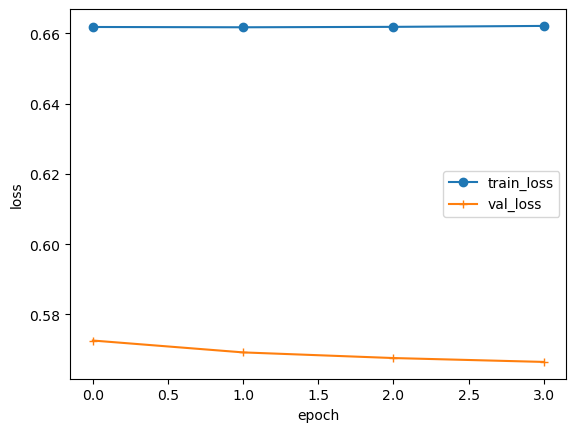

In [39]:
import matplotlib.pyplot as plt
plt.plot(train_losses, marker='o', label='train_loss')
plt.plot(val_losses, marker='+', label='val_loss')
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

In [40]:
torch.save(model.state_dict(), "bert-qqp-sbjt.pt")

In [41]:
def evaluate(model: BERTClassification, dataloader, device):
    model.eval()
    total_correct = 0
    total = 0
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Validation "):
            batch = tuple(t.to(device) for t in batch)
            tokens, segment_ids, input_mask, labels = batch
            logits = model(tokens, segment_ids, input_mask)
            preds = logits.argmax(dim=-1)
            total_correct += (preds == labels).sum()
            total += logits.size(0)
    # print(f"Val loss: {val_loss}")
    acc = total_correct / total
    return acc

In [42]:
acc = evaluate(model, val_loader, device)
print(f"Val acc: {acc*100:.2f}")

Validation :   0%|          | 0/1263 [00:00<?, ?it/s]

Validation : 100%|██████████| 1263/1263 [00:13<00:00, 90.94it/s]

Val acc: 81.25


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

CHECKPOINT = "google-bert/bert-base-uncased"
MAX_LEN = 128
BATCH_SIZE = 16
NUM_EPOCHS = 3
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01

hf_tokenizer = AutoTokenizer.from_pretrained(CHECKPOINT, use_fast=True)
hf_model = AutoModelForSequenceClassification.from_pretrained(
    CHECKPOINT,
    num_labels=2,
)

print(hf_tokenizer)
print("vocab size:", hf_tokenizer.vocab_size)
print("model vocab size:", hf_model.config.vocab_size)
print("hidden size:", hf_model.config.hidden_size)
print("num layers:", hf_model.config.num_hidden_layers)
print("pad token id:", hf_tokenizer.pad_token_id)
print("cls token id:", hf_tokenizer.cls_token_id)
print("sep token id:", hf_tokenizer.sep_token_id)

# Compatibility check: the tokenizer's IDs index the model's embedding matrix.
assert hf_tokenizer.vocab_size == hf_model.get_input_embeddings().num_embeddings

In [44]:
# Load the same QQP parquet files as in the original notebook.
df_train = pd.read_parquet("train-00000-of-00001.parquet", engine="pyarrow")
df_val = pd.read_parquet("validation-00000-of-00001.parquet", engine="pyarrow")

print(df_train.columns.tolist())
print("train:", len(df_train), "validation:", len(df_val))
print(df_train[["question1", "question2", "label"]].head())

['question1', 'question2', 'label', 'idx']
train: 363846 validation: 40430
                                           question1  \
0  How is the life of a math student? Could you d...   
1                How do I control my horny emotions?   
2       What causes stool color to change to yellow?   
3                        What can one do after MBBS?   
4  Where can I find a power outlet for my laptop ...   

                                           question2  label  
0  Which level of prepration is enough for the ex...      0  
1                 How do you control your horniness?      1  
2  What can cause stool to come out as little balls?      0  
3                       What do i do after my MBBS ?      1  
4  Would a second airport in Sydney, Australia be...      0  


In [45]:
class QQPDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        return str(row["question1"]), str(row["question2"]), int(row["label"])


def qqp_collate_fn(batch):
    question1, question2, labels = zip(*batch)

    # The HF tokenizer creates the correct BERT pair format:
    # [CLS] question1 [SEP] question2 [SEP]
    # and the matching token_type_ids / attention_mask.
    encoded = hf_tokenizer(
        list(question1),
        list(question2),
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt",
    )

    encoded["labels"] = torch.tensor(labels, dtype=torch.long)
    return encoded


train_dataset = QQPDataset(df_train)
val_dataset = QQPDataset(df_val)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=qqp_collate_fn,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=qqp_collate_fn,
    pin_memory=torch.cuda.is_available(),
)

In [ ]:
# Inspect one batch before training.
batch = next(iter(train_loader))
for key, value in batch.items():
    print(key, value.shape, value.dtype)

print("input_ids[0]:", batch["input_ids"][0])
print("tokens[0]:", hf_tokenizer.convert_ids_to_tokens(batch["input_ids"][0].tolist()))

In [47]:
hf_model = hf_model.to(device)

optimizer = torch.optim.AdamW(
    hf_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

num_training_steps = NUM_EPOCHS * len(train_loader)
num_warmup_steps = int(0.1 * num_training_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps,
)

use_amp = device.type == "cuda"
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

print("device:", device)
print("trainable parameters:", sum(p.numel() for p in hf_model.parameters() if p.requires_grad))

device: cuda
trainable parameters: 109483778


In [48]:
def train_epoch(model, dataloader, optimizer, scheduler, device, scaler, epoch):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    progress = tqdm(dataloader, desc=f"[Epoch {epoch + 1:2d}] Train")

    for batch in progress:
        batch = {k: v.to(device, non_blocking=True) for k, v in batch.items()}

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=use_amp):
            outputs = model(**batch)
            loss = outputs.loss

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        predictions = outputs.logits.argmax(dim=-1)
        labels = batch["labels"]

        total_loss += loss.item() * labels.size(0)
        total_correct += (predictions == labels).sum().item()
        total_examples += labels.size(0)

        progress.set_postfix(
            loss=f"{total_loss / total_examples:.4f}",
            acc=f"{total_correct / total_examples:.4f}"
        )

    return total_loss / total_examples, total_correct / total_examples


@torch.no_grad()
def evaluate(model, dataloader, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for batch in tqdm(dataloader, desc="Validation"):
        batch = {k: v.to(device, non_blocking=True) for k, v in batch.items()}
        outputs = model(**batch)

        labels = batch["labels"]
        predictions = outputs.logits.argmax(dim=-1)

        total_loss += outputs.loss.item() * labels.size(0)
        total_correct += (predictions == labels).sum().item()
        total_examples += labels.size(0)

    return total_loss / total_examples, total_correct / total_examples

In [ ]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_val_acc = -1.0

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(
        hf_model,
        train_loader,
        optimizer,
        scheduler,
        device,
        scaler,
        epoch,
    )

    val_loss, val_acc = evaluate(hf_model, val_loader, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch + 1:2d} | "
        f"Train loss: {train_loss:.4f} | "
        f"Train acc: {train_acc:.4f} | "
        f"Val loss: {val_loss:.4f} | "
        f"Val acc: {val_acc:.4f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        hf_model.save_pretrained("bert-qqp-hf-best")
        hf_tokenizer.save_pretrained("bert-qqp-hf-best")
        print(f"Saved best checkpoint with validation accuracy {best_val_acc:.4f}")

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.plot(train_losses, marker="o", label="train loss")
ax.plot(val_losses, marker="+", label="val loss")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.legend()
plt.show()

fig, ax = plt.subplots()
ax.plot(train_accs, marker="o", label="train accuracy")
ax.plot(val_accs, marker="+", label="validation accuracy")
ax.set_xlabel("epoch")
ax.set_ylabel("accuracy")
ax.legend()
plt.show()

In [51]:
hf_model.save_pretrained("bert-qqp-hf-best")
hf_tokenizer.save_pretrained("bert-qqp-hf-best")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.46it/s]


('bert-qqp-hf-best\\tokenizer_config.json', 'bert-qqp-hf-best\\tokenizer.json')

In [52]:
# Reload the best checkpoint to verify save/load compatibility.
best_model = AutoModelForSequenceClassification.from_pretrained("bert-qqp-hf-best").to(device)
best_tokenizer = AutoTokenizer.from_pretrained("bert-qqp-hf-best", use_fast=True)

best_loss, best_acc = evaluate(best_model, val_loader, device)
print(f"Best checkpoint validation loss: {best_loss:.4f}")
print(f"Best checkpoint validation accuracy: {best_acc * 100:.2f}%")

Validation: 100%|██████████| 2527/2527 [03:11<00:00, 13.19it/s]

Best checkpoint validation loss: 0.4825
Best checkpoint validation accuracy: 73.71%


In [53]:
# Example inference on a question pair.
def predict_qqp(question1, question2, model=best_model, tokenizer=best_tokenizer):
    model.eval()
    encoded = tokenizer(
        question1,
        question2,
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt",
    )
    encoded = {k: v.to(device) for k, v in encoded.items()}
    with torch.no_grad():
        logits = model(**encoded).logits
    pred = logits.argmax(dim=-1).item()
    return pred, logits.softmax(dim=-1)[0].cpu()

q1 = "How can I learn Python?"
q2 = "What is the best way to learn Python?"
label, probabilities = predict_qqp(q1, q2)
print("predicted label:", label)
print("probabilities [not_duplicate, duplicate]:", probabilities)


predicted label: 1
probabilities [not_duplicate, duplicate]: tensor([0.2520, 0.7480])
